<a href="https://colab.research.google.com/github/Leofter/Customer_Churn_Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de biblioteca

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

#### Dados

In [ ]:
dados = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [ ]:
import pandas as pd
atributos = ['customerID','gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges','Churn']
df = pd.read_csv(dados, header=0, names = atributos)
df.columns = atributos
print(df.head(3))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  TotalCharges Churn  
0  E

In [ ]:
print(df.shape)


(7043, 21)


In [ ]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [ ]:
# print(df.groupby('PaymentMethod').size())
# print(df.groupby('TotalCharges').size())
# print(df.groupby('gender').size())
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import pandas as pd

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


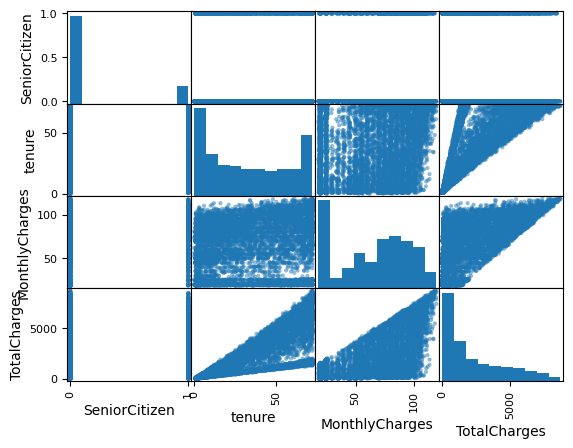

In [ ]:
scatter_matrix(df)
plt.show()

como estava antes:

import pandas as pd

array = df.values
print(array)

# Separate features (x) and target (y)
x = df.drop('Churn', axis=1)
y = df['Churn']

# Drop customerID as it's an identifier and not a feature for the model
x = x.drop('customerID', axis=1)

# Convert categorical features in x to numerical using one-hot encoding
x = pd.get_dummies(x, drop_first=True) # drop_first=True avoids multicollinearity

# Convert the target variable 'Churn' from 'Yes'/'No' to 1/0
y = y.map({'Yes': 1, 'No': 0})

# Now proceed with train-test split
porcentagem_dados_validacao = 0.20
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=porcentagem_dados_validacao, random_state=7)

In [ ]:
import pandas as pd

array = df.values
print(array)

# Separate features (x) and target (y)
x = df.drop('Churn', axis=1)
y = df['Churn']

# Drop customerID as it's an identifier and not a feature for the model
x = x.drop('customerID', axis=1)

# Convert categorical features in x to numerical using one-hot encoding
x = pd.get_dummies(x, drop_first=True) # drop_first=True avoids multicollinearity

# Convert the target variable 'Churn' from 'Yes'/'No' to 1/0
y = y.map({'Yes': 1, 'No': 0})

# Drop rows with any NaN values from x. This handles the NaNs in 'TotalCharges'.
x.dropna(inplace=True)
# Also ensure y aligns with the dropped rows in x
y = y[x.index]

# Now proceed with train-test split
porcentagem_dados_validacao = 0.20
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=porcentagem_dados_validacao, random_state=7)

[['7590-VHVEG' 'Female' 0 ... 29.85 29.85 'No']
 ['5575-GNVDE' 'Male' 0 ... 56.95 1889.5 'No']
 ['3668-QPYBK' 'Male' 0 ... 53.85 108.15 'Yes']
 ...
 ['4801-JZAZL' 'Female' 0 ... 29.6 346.45 'No']
 ['8361-LTMKD' 'Male' 1 ... 74.4 306.6 'Yes']
 ['3186-AJIEK' 'Male' 0 ... 105.65 6844.5 'No']]


# Modelos
> Regressão Logística (LR)
Análise Linear Discriminante (LDA)
K-vizinhos mais próximos (KNN).
Árvores de Classificação (Decision Tree) e Regressão (CART).
Gaussian Naive Bayes (NB).
Support Vector Machines (SVM).

In [ ]:
LogisticRegression_model = LogisticRegression(solver='liblinear', multi_class='ovr')
cross_score = model_selection.cross_val_predict(LogisticRegression_model, x_train, y_train, cv=5)
print('score é: ' + str(cross_score) + ' usando: ' + str(LogisticRegression_model))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values